# Benchmark Analysis

This notebook uses the benchmark analysis API from `examples/benchmark_runner.py` to:

1. load a full benchmark session
2. group runs by restart family and select the top `K` groups by minimal `best_loss`
3. plot aggregate loss lines for the selected subset
4. load the best model from each selected restart group and scatter plot samples


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from benchmark_runner import (
    entries_to_frame,
    entry_arrays,
    get_lines,
    import_runtime_dependencies,
    load_entry_model,
    load_experiment_entries,
    restart_group_columns,
)


In [2]:
session_dir = Path('./results/ce_8gaussians_arch_search/benchmark_20260707_101906/')
entries = load_experiment_entries(session_dir)

print(f'loaded {len(entries)} entries from {session_dir}')
entries[0].keys()


loaded 1344 entries from results/ce_8gaussians_arch_search/benchmark_20260707_101906


dict_keys(['run_index', 'run_id', 'restart_index', 'problem', 'resolved_problem', 'architecture', 'method', 'method_kwargs', 'run_dir', 'checkpoints', 'array_names', 'loss', 'grad_norm', 'natural_grad_norm', 'best_loss', 'best_iteration', 'final_loss'])

In [3]:
def select_top_k_restart_groups(entries, k):
    frame = entries_to_frame(entries)
    group_cols = restart_group_columns(frame)

    if not group_cols:
        summary = frame[['entry_index', 'best_loss']].copy()
        summary['group_rank'] = 0
        return entries, summary

    summary = (
        frame.groupby(group_cols, sort=False, dropna=False, as_index=False)
        .agg(
            min_best_loss=('best_loss', 'min'),
            n_restarts=('entry_index', 'count'),
        )
        .sort_values('min_best_loss', ascending=True, kind='stable')
        .head(k)
        .reset_index(drop=True)
    )
    summary['group_rank'] = np.arange(len(summary))

    selected_frame = frame.merge(summary[group_cols], on=group_cols, how='inner')
    selected_indices = selected_frame['entry_index'].tolist()
    subset_entries = [entries[index] for index in selected_indices]
    return subset_entries, summary


def best_entry_per_restart_group(entries):
    frame = entries_to_frame(entries)
    group_cols = restart_group_columns(frame)

    if not group_cols:
        if not entries:
            return []
        best_index = int(frame['best_loss'].idxmin())
        return [entries[int(frame.loc[best_index, 'entry_index'])]]

    best_row_indices = (
        frame.groupby(group_cols, sort=False, dropna=False)['best_loss']
        .idxmin()
        .tolist()
    )
    entry_indices = frame.loc[best_row_indices, 'entry_index'].tolist()
    return [entries[int(index)] for index in entry_indices]


In [4]:
top_k = 5
subset_entries, subset_summary = select_top_k_restart_groups(entries, top_k)
best_entries = best_entry_per_restart_group(subset_entries)

print(f'selected {len(subset_entries)} entries across {len(best_entries)} restart groups')
subset_summary


selected 30 entries across 5 restart groups


,method,method_kwargs.max_iterations,method_kwargs.batch_size,method_kwargs.N_monte_carlo,method_kwargs.master_seed,method_kwargs.plot_every,method_kwargs.linear_solver_tolerance,method_kwargs.step_size,method_kwargs.linear_solver_regularization,architecture.rhs.model,...,architecture.ode_method,architecture.adaptive,architecture.h_max,problem.functional.kind,problem.distribution.name,problem.distribution.resample_each,problem.distribution.seed,min_best_loss,n_restarts,group_rank
0,ngd,3000,512,512,42,600,0.000001,0.010,0.0010,MLP,...,rk45,true,0.3,CrossEntropy,eight_gaussians,32,3,0.177886,6,0
1,ngd,3000,512,512,42,600,0.000001,0.001,0.0001,MLP,...,rk45,true,0.3,CrossEntropy,eight_gaussians,32,3,0.216599,6,1
2,ngd,3000,512,512,42,600,0.000001,0.010,0.0100,MLP,...,rk45,true,0.3,CrossEntropy,eight_gaussians,32,3,0.509792,6,2
3,ngd,3000,512,512,42,600,0.000001,0.010,0.0100,MLP,...,rk45,true,0.3,CrossEntropy,eight_gaussians,32,3,0.602257,6,3
4,ngd,3000,512,512,42,600,0.000001,0.010,0.0100,MLP,...,rk45,true,0.3,CrossEntropy,eight_gaussians,32,3,0.622732,6,4


In [5]:
def plot_line_groups(groups):
    for group in groups:
        fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')

        for line in group['lines']:
            style = line.get('style', {})
            color = style.get('color')
            linestyle = style.get('linestyle', '-')
            linewidth = style.get('linewidth', 1.5)

            if 'loss_mean' in line:
                x = np.arange(len(line['loss_mean']))
                ax.plot(
                    x,
                    line['loss_mean'],
                    label=line['label'],
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                )
                if 'loss_lower' in line and 'loss_upper' in line:
                    ax.fill_between(
                        x,
                        line['loss_lower'],
                        line['loss_upper'],
                        color=color,
                        alpha=0.2,
                    )
            else:
                loss = np.asarray(line['loss'], dtype=float)
                x = np.arange(len(loss))
                ax.plot(
                    x,
                    loss,
                    label=line['label'],
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                )

        ax.set_title(group['title'])
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        ax.set_ylim(
            bottom=subset_summary['min_best_loss'].min(),
            top=line['loss_mean'][0], )
        ax.grid()
        ax.legend()
        plt.show()


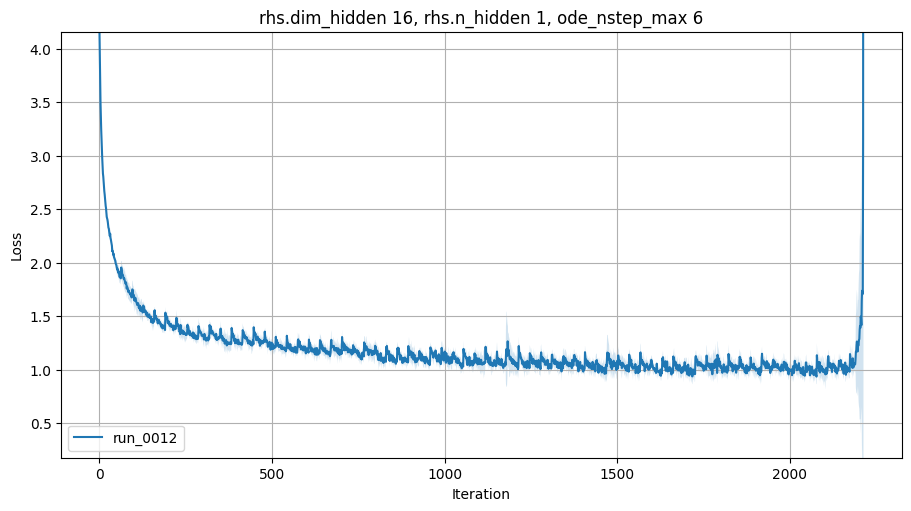

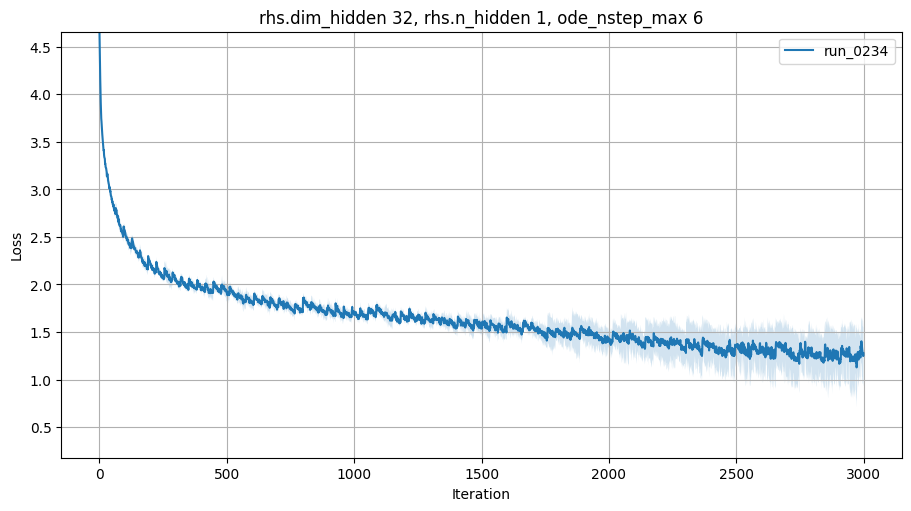

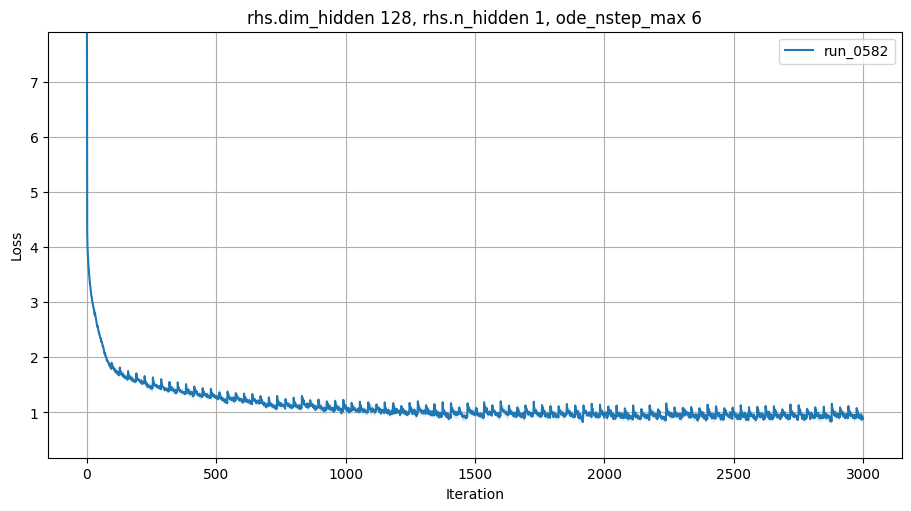

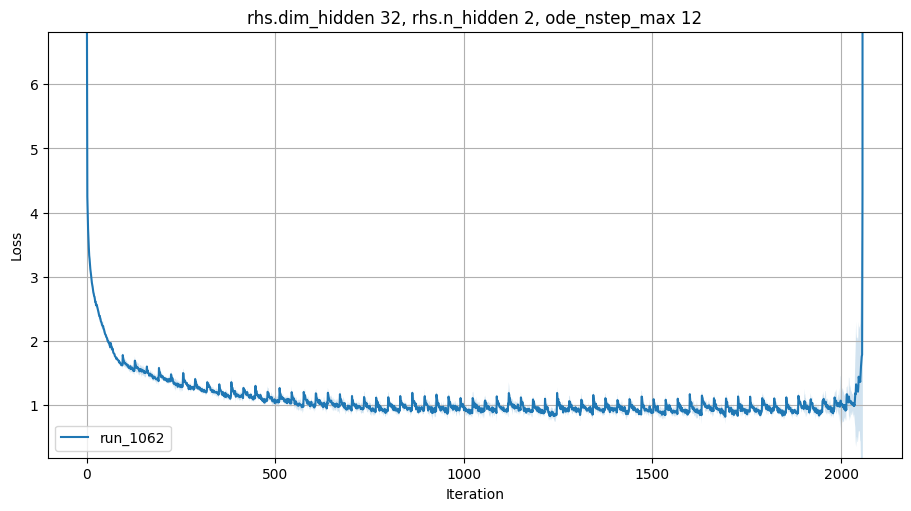

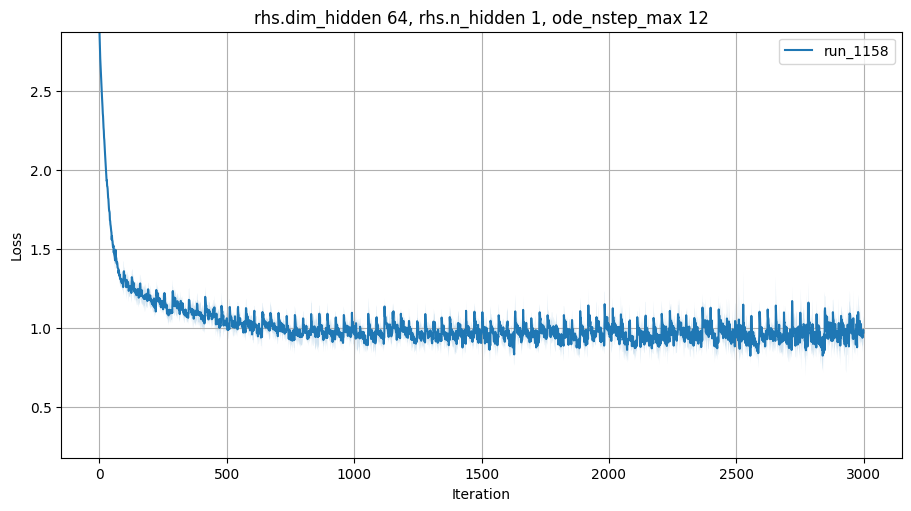

In [6]:
style_channels = {
    'colormap': ['Blues', 'Reds', 'Greens', 'Purples'],
    'linestyle': ['-', '--', ':', '-.'],
}

groups = get_lines(subset_entries, style_channels)
plot_line_groups(groups)


In [9]:
def scatter_best_entries(entries, checkpoint_key='best', n_samples=512):
    if not entries:
        return

    deps = import_runtime_dependencies()
    ncols = min(3, len(entries))
    nrows = int(np.ceil(len(entries) / ncols))
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 4 * nrows),
        layout='constrained',
    )
    axs = np.atleast_1d(axs).ravel()

    for ax, entry in zip(axs, entries, strict=False):
        model = load_entry_model(entry, key=checkpoint_key)
        samples = model.sample(n_samples, deps['nnx'].Rngs(0))

        if samples.shape[-1] >= 2:
            ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.7)
            ax.set_xlabel('x[0]')
            ax.set_ylabel('x[1]')
        else:
            ax.hist(samples[:, 0], bins=40)

        ax.set_title(
            f"{entry['run_id']}\n"
            f"best_loss={entry.get('best_loss', np.nan):.3e}, restart={entry.get('restart_index')}"
        )
        ax.grid()

    for ax in axs[len(entries):]:
        ax.axis('off')

    plt.show()


ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Home/optimier/aksenov/miniconda3/envs/fps_cuda12/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x146e28d8d200> is already entered
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-2' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Home/optimier/aksenov/miniconda3/envs/fps_cuda12/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-3' coro=<Kernel.shell_main() running at /Home/optimier/aksenov/miniconda3/envs/fps_cuda12/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Home/optimier/aksenov/miniconda3/envs/fps_cuda12/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:56

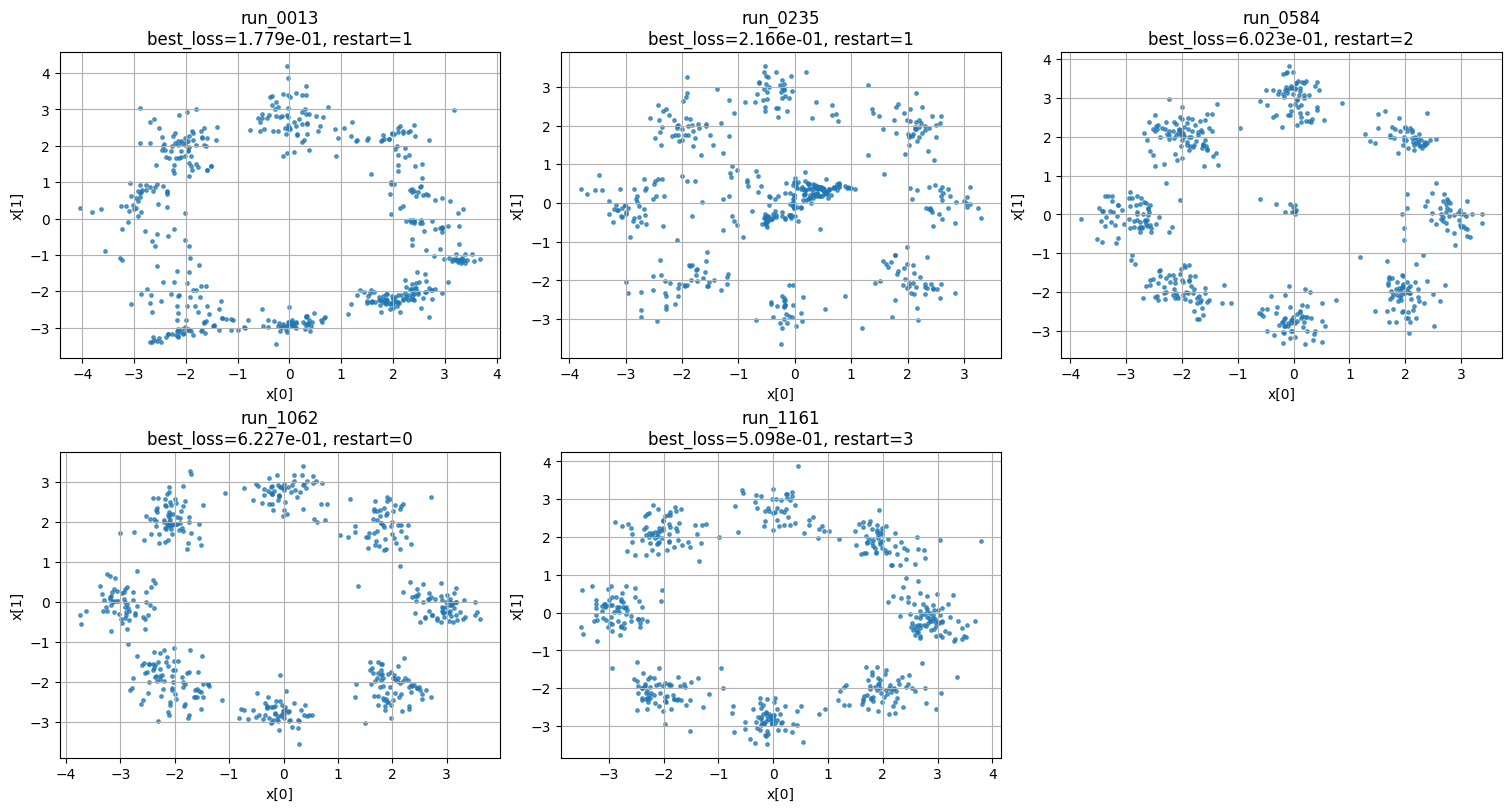

In [10]:
scatter_best_entries(best_entries, checkpoint_key='best', n_samples=512)


In [ ]:
entries_to_frame(subset_entries).head()


In [11]:
subset_entries[0]

{'run_index': 12,
 'run_id': 'run_0012',
 'restart_index': 0,
 'problem': {'functional': {'kind': 'CrossEntropy'},
  'distribution': {'name': 'eight_gaussians', 'resample_each': 32, 'seed': 3}},
 'resolved_problem': {'dim': 2,
  'dim_source': 'data',
  'distribution_name': 'eight_gaussians'},
 'architecture': {'rhs': {'model': 'MLP',
   'activation': 'tanh',
   'dim_hidden': 16,
   'n_hidden': 1},
  'divergence_method': 'hutchinson',
  'ode_nstep_max': 6,
  'ode_method': 'rk45',
  'adaptive': 'true',
  'h_max': 0.3},
 'method': 'ngd',
 'method_kwargs': {'max_iterations': 3000,
  'batch_size': 512,
  'N_monte_carlo': 512,
  'master_seed': 42,
  'plot_every': 600,
  'linear_solver_tolerance': 1e-06,
  'step_size': 0.01,
  'linear_solver_regularization': 0.001},
 'run_dir': PosixPath('results/ce_8gaussians_arch_search/benchmark_20260707_101906/runs/run_0012'),
 'checkpoints': {'best': PosixPath('/Home/optimier/aksenov/Documents/code/NeuRiPP/examples/results/ce_8gaussians_arch_search/bench